## Hierarchial Clustering

In [1]:
from scipy.cluster.hierarchy import linkage, dendrogram 
import pandas as pd
import numpy as np 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 

In [2]:
featureSelection_df = pd.read_csv('ga_selected_features.csv') 

In [3]:
featureSelection_df.head()

,loan_percent_income,loan_intent_HOMEIMPROVEMENT,loan_grade_B,loan_grade_C,loan_grade_E,cb_person_default_on_file_Y
0,-0.656393,False,True,False,False,False
1,3.744111,False,False,True,False,False
2,3.369600,False,False,True,False,False
3,3.556855,False,False,True,False,True
4,0.748023,False,False,False,False,False


In [4]:
xcluster = featureSelection_df

In [6]:
range_n_clusters = range(2, 10)     # Try cluster numbers from 2 to 9

### Single Linkage

In [7]:
single_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='single',
        metric= 'euclidean' 
    )
    
    labels = model.fit_predict(xcluster)
    score = silhouette_score(xcluster, labels)
    single_link_scores.append(score)

print("Single scores:", single_link_scores)

Single scores: [0.48000592333431574, 0.22300318331614838, 0.13648480618476747, 0.12435551462719907, 0.1067898146135051, 0.1532240639352132, 0.11087429921903609, 0.11796694538214338]


### Ward Linkage

In [8]:
ward_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(xcluster)
    score = silhouette_score(xcluster, labels)
    ward_link_scores.append(score)

print("Ward scores:", ward_link_scores)

Ward scores: [0.3918962546600575, 0.2528037257510319, 0.29256625208949066, 0.26163921512779864, 0.2776566676536505, 0.3267695261426691, 0.3463469727822169, 0.35252173084341626]


### Complete Linkage

In [9]:
complete_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='complete', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(xcluster)
    score = silhouette_score(xcluster, labels)
    complete_link_scores.append(score)

print("Complete scores:", complete_link_scores)

Complete scores: [0.4866808331008469, 0.34850716461005665, 0.3473749746491673, 0.33888105960638887, 0.17716959270037788, 0.16037406291134682, 0.15935041005719683, 0.1563184260792386]


### Average Linkage

In [10]:
average_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='average', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(xcluster)
    score = silhouette_score(xcluster, labels)
    average_link_scores.append(score)

print("Average scores:", average_link_scores)

Average scores: [0.41765306630487653, 0.3925703461288619, 0.3830367911644424, 0.38280103036675434, 0.3199696297930052, 0.3188709030001763, 0.22067428478493575, 0.20835115655450243]


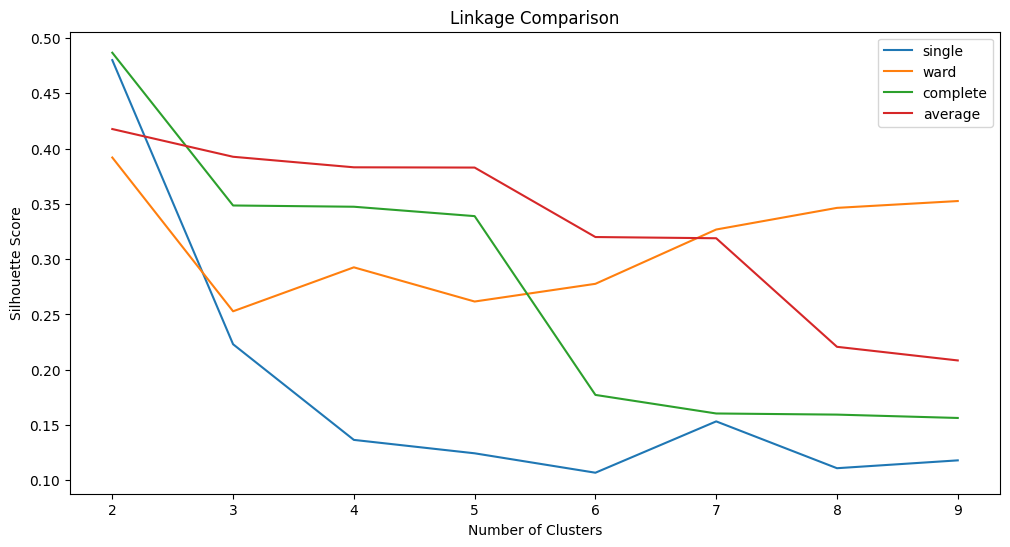

In [11]:
plt.figure(figsize= (12, 6))
plt.plot(range_n_clusters, single_link_scores, label='single')
plt.plot(range_n_clusters, ward_link_scores, label='ward')
plt.plot(range_n_clusters, complete_link_scores, label='complete')
plt.plot(range_n_clusters, average_link_scores, label='average')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Linkage Comparison")
plt.legend()
plt.show()

In [12]:
def best_k(scores, k_range):
    best_k = k_range[np.argmax(scores)]
    best_score = max(scores)
    return best_k, best_score

In [13]:
print("Single:", best_k(single_link_scores, range_n_clusters))
print("Ward:", best_k(ward_link_scores, range_n_clusters))
print("Complete:", best_k(complete_link_scores, range_n_clusters))
print("Average:", best_k(average_link_scores, range_n_clusters))

Single: (2, 0.48000592333431574)
Ward: (2, 0.3918962546600575)
Complete: (2, 0.4866808331008469)
Average: (2, 0.41765306630487653)


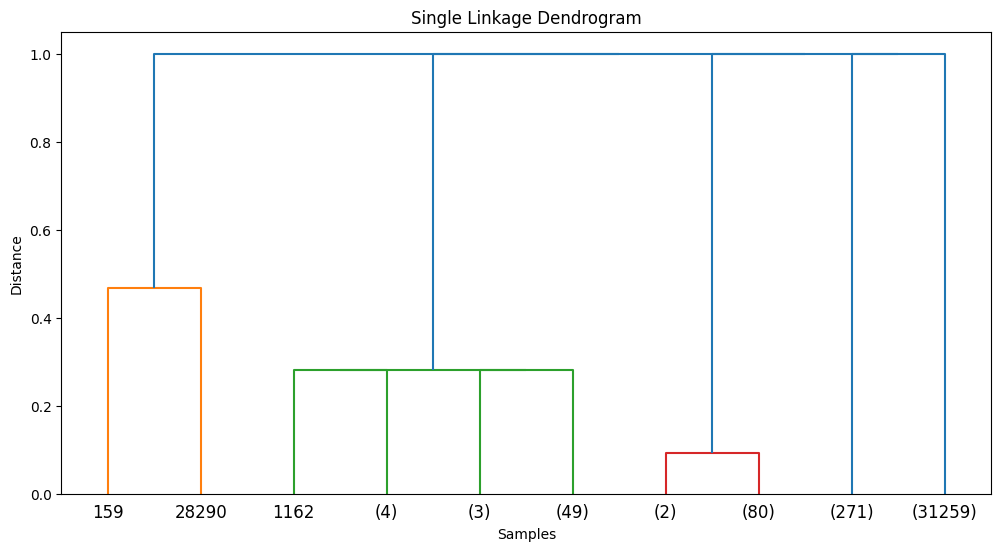

In [18]:
Z_single = linkage(xcluster, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z_single, truncate_mode='level', p=3)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

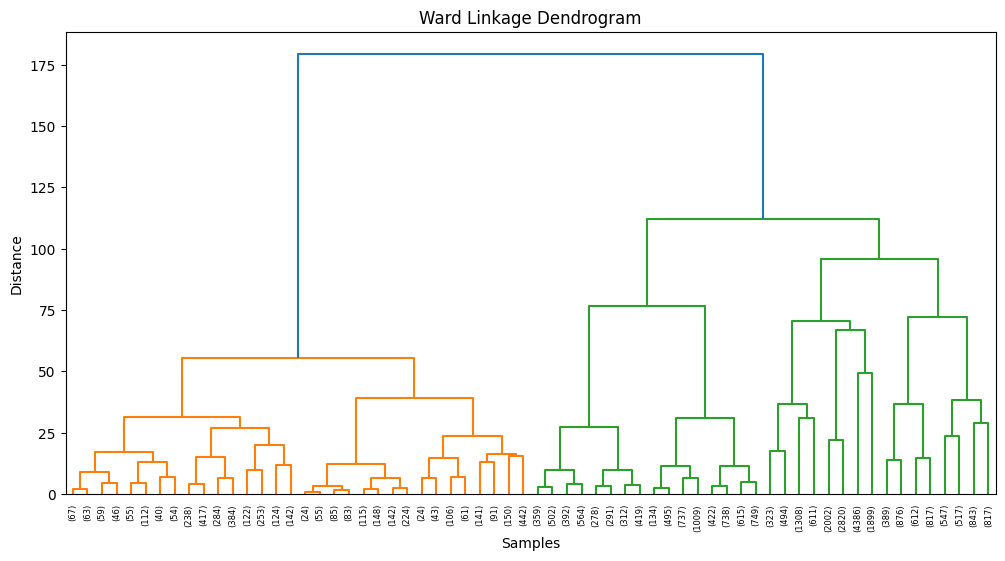

In [19]:
Z_ward = linkage(xcluster, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title("Ward Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

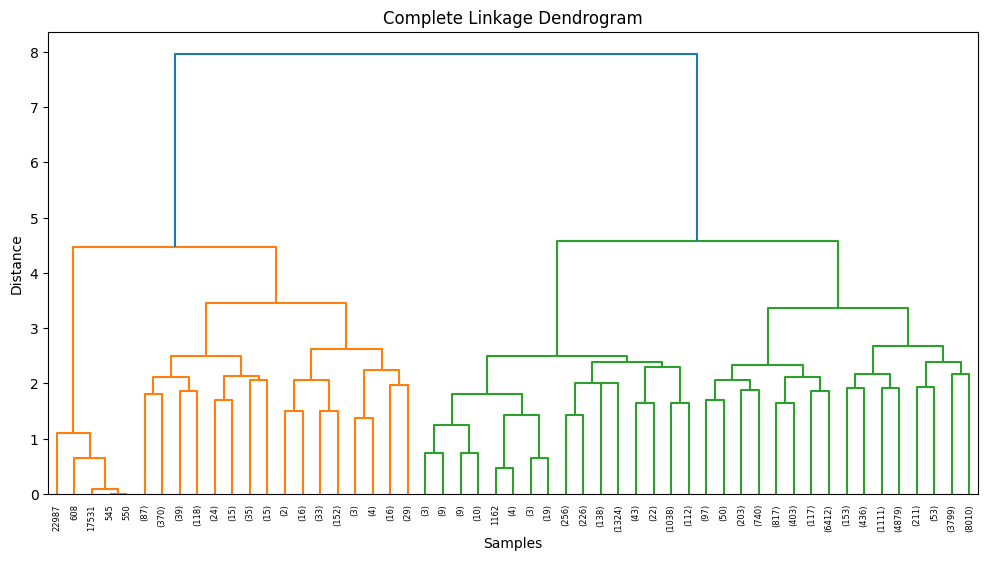

In [20]:
Z_complete = linkage(xcluster, method='complete')

plt.figure(figsize=(12, 6))
dendrogram(Z_complete, truncate_mode='level', p=5)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

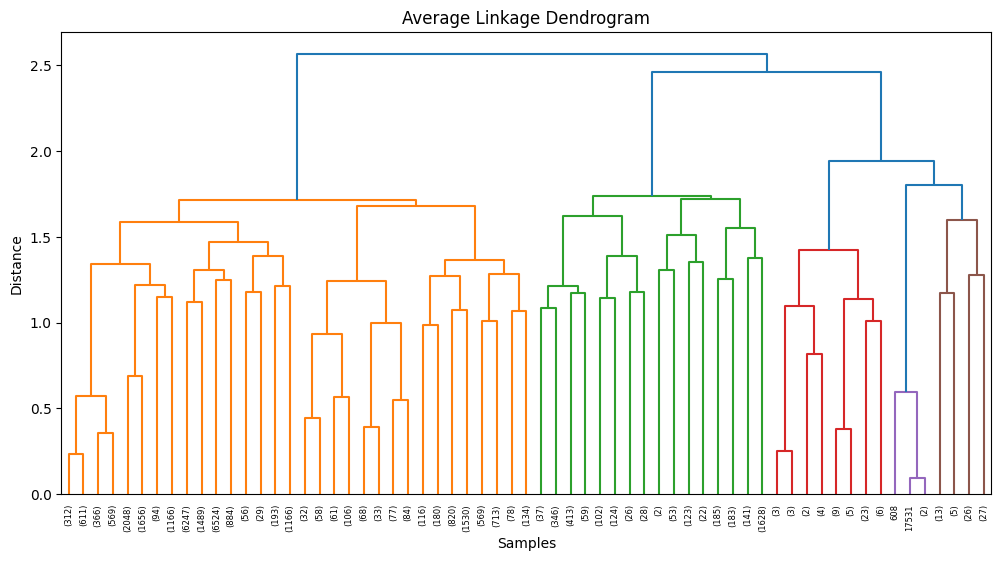

In [21]:
Z_average = linkage(xcluster, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z_average, truncate_mode='level', p=5)
plt.title("Average Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Final Model

In [22]:
final_model2 = AgglomerativeClustering(n_clusters= 3, linkage= 'ward', metric= 'euclidean') # Default metric is `euclidean` 

clusters2 = final_model2.fit_predict(xcluster)

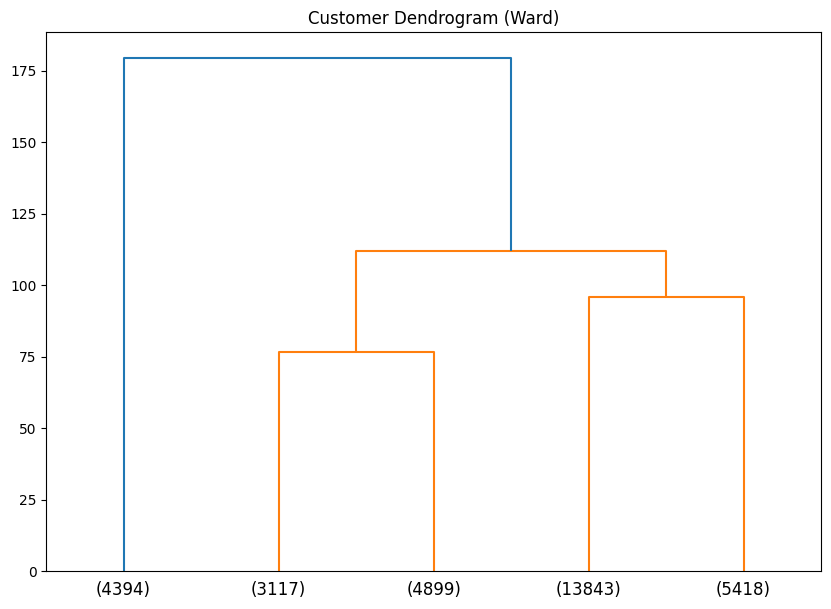

In [25]:
import scipy.cluster.hierarchy as shc


plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (Ward)")
# Use a sample so the plot is readable
dend = shc.dendrogram(shc.linkage(xcluster, method='ward'),truncate_mode="lastp",p=5)
plt.show()

In [26]:
data_with_clusters2 = pd.read_csv('cleaned_data.csv') 

In [27]:
data_with_clusters2['ward_cluster'] = clusters2

In [28]:
data_with_clusters2.head(30) 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,True,False,False,False,False,False,False,2
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,False,True,False,False,False,False,False,1
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,False,True,False,False,False,False,False,1
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,False,True,False,False,False,False,True,1
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,True,False,False,False,False,False,False,False,0
5,26,77100,8.0,35000,0.1242,1,0.45,3,False,False,...,False,False,True,False,False,False,False,False,False,1
6,24,78956,5.0,35000,0.1111,1,0.44,4,False,False,...,False,False,True,False,False,False,False,False,False,1
7,24,83000,8.0,35000,0.0890,1,0.42,2,False,False,...,True,False,False,False,False,False,False,False,False,1
8,22,85000,6.0,35000,0.1037,1,0.41,4,False,False,...,False,True,True,False,False,False,False,False,False,1
9,21,10000,2.0,4500,0.0863,1,0.45,2,False,True,...,False,False,False,False,False,False,False,False,False,1


In [29]:
data_with_clusters2.tail(20)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
31651,54,129000,6.0,9000,0.114900,1,0.07,24,False,False,...,False,False,True,False,False,False,False,False,False,2
31652,61,160000,30.0,24000,0.103800,0,0.15,21,False,False,...,True,False,True,False,False,False,False,False,False,2
31653,52,71520,0.0,7000,0.168200,1,0.10,24,False,False,...,False,False,False,False,False,True,False,False,True,0
31654,53,45000,0.0,5600,0.137900,0,0.12,28,False,False,...,True,False,False,True,False,False,False,False,False,0
31655,57,40000,1.0,15000,0.089000,1,0.38,21,False,False,...,False,False,False,False,False,False,False,False,False,1
31656,52,30000,6.0,5000,0.127300,0,0.17,18,False,False,...,False,True,False,True,False,False,False,False,False,0
31657,53,85000,2.0,8000,0.077400,0,0.09,26,False,False,...,True,False,False,False,False,False,False,False,False,0
31658,60,49008,5.0,12000,0.137900,0,0.24,21,False,True,...,True,False,False,True,False,False,False,False,True,0
31659,51,60000,1.0,7500,0.073284,0,0.13,23,False,False,...,True,False,False,False,False,False,False,False,False,0
31660,58,72000,5.0,4500,0.109958,0,0.06,23,False,False,...,False,False,True,False,False,False,False,False,False,0


In [30]:
data_with_clusters2['ward_cluster'].value_counts()

ward_cluster
0    19261
2     8016
1     4394
Name: count, dtype: int64

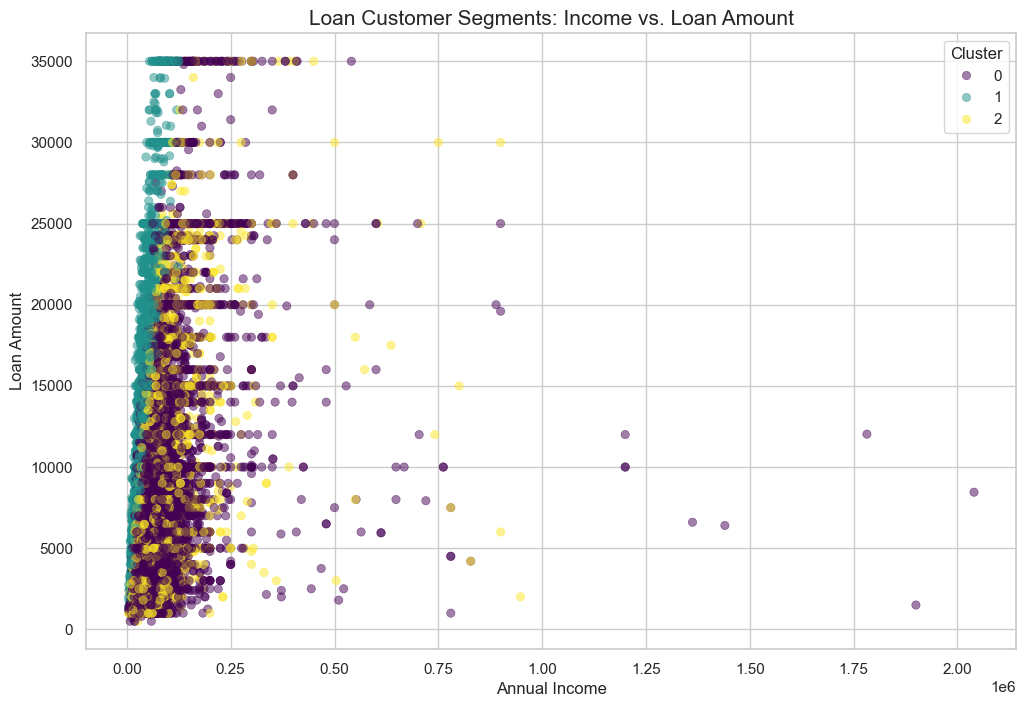

In [32]:
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Using the original feature names for the axes
# I've added a log scale for income in case you have high-earners that squash the plot
plot = sns.scatterplot(
    data=data_with_clusters2, 
    x='person_income', 
    y='loan_amnt', 
    hue='ward_cluster', 
    palette='viridis', 
    alpha=0.5,
    edgecolor=None
)

plt.title('Loan Customer Segments: Income vs. Loan Amount', fontsize=15)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Cluster')

# Optional: If your income data has extreme outliers, uncomment the line below:
# plt.xscale('log') 

plt.show()

In [31]:
# This gives you the average 'vibe' of each cluster
profile1 = data_with_clusters2.groupby('ward_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'loan_status']].mean()
print(profile1)
print('-------------------------------')

 

profile2 = data_with_clusters2.groupby('ward_cluster')['cb_person_default_on_file_Y'].value_counts() 
print(profile2)

              person_age  person_income     loan_amnt  loan_int_rate  \
ward_cluster                                                           
0              27.920513   69814.214319   8461.637506       0.109387   
1              27.506145   44052.919436  15440.583751       0.114109   
2              27.640843   68277.254242   9032.288548       0.110013   

              cb_person_cred_hist_length  loan_status  
ward_cluster                                           
0                               5.905664     0.187685  
1                               5.696859     0.591716  
2                               5.784805     0.090319  
-------------------------------
ward_cluster  cb_person_default_on_file_Y
0             False                          14406
              True                            4855
1             False                           3636
              True                             758
2             False                           8016
Name: count, dtype: int64


## Customer Persona Analysis
Based on the Ward Linkage clustering results, the dataset has been segmented into three distinct groups. While there is a significant difference in cluster sizes, each group reveals a very specific financial profile.

---

### Cluster 0: "The Stable Majority"
* Average Age: ~28 years (Early to mid-career).

* Average Income: ~$69,814 (Highest income group).

* Loan Behavior: Moderate loan amounts (~$8.4k) with the lowest interest rates (~10.9%).

* Default Profile: Low historical default rate (approx. 25% of this group has a previous default).

> **Business Insight**: This is your core "safe" segment. These individuals have high incomes relative to their loan sizes and show high creditworthiness. They are ideal candidates for standard financial products and loyalty programs.

---

### Cluster 1: "The High-Leverage Borrowers"
* Average Age: ~27 years (Young professionals).

* Average Income: ~$44,053 (Lowest income group).

* Loan Behavior: Highest loan amounts (~$15.4k) and high interest rates (~11.4%).

* Default Profile: Extreme risk; the loan_status is 0.59, and nearly 67% have a history of default.

> **Business Insight**: This segment represents the highest financial risk. Their debt-to-income ratio is significantly higher than other groups. This cluster requires intensive monitoring, stricter approval protocols, and potentially higher collateral requirements.

---

### Cluster 2: "The Elite Low-Risk Niche"
* Average Age: ~27 years.

* Average Income: ~$68,277 (Strong income level).

* Loan Behavior: Moderate loans (~$9k) with competitive interest rates (~11.0%).

* Default Profile: The most reliable group; only 9% of this cluster has a loan_status of 1 (defaulted), despite a moderate history of previous defaults on file.

> **Business Insight**: This is a small but highly valuable "Premium" segment. Despite having some historical defaults on file, their current behavior is exceptionally stable. They represent a prime target for "credit repair" products or high-limit offers due to their current high repayment reliability.

## Final Insight
The Ward Linkage method successfully isolated a critical high-risk group (Cluster 1) that accounts for a large portion of potential defaults. While Cluster 0 represents the volume of the business, the clear differentiation of Cluster 2 shows that income alone doesn't determine risk—behavioral patterns do. This segmentation provides a clear roadmap for risk-adjusted pricing and targeted credit limit adjustments.

In [33]:
cluster_map = {
    0: 'The Stable Majority',  # They can afford larger loans, Not necessarily safest, but financially strong
    1: 'The High-Leverage Borrowers', # Banks trust them → lowest interest,  Careful borrowers → smaller loans
    2: 'The Elite Low-Risk Niche' # Clear risk profile, Even with smaller loans → high interest
}

data_with_clusters2['cluster_name'] = data_with_clusters2['ward_cluster'].map(cluster_map)

# Now your counts are readable!
print(data_with_clusters2['cluster_name'].value_counts())

cluster_name
The Stable Majority            19261
The Elite Low-Risk Niche        8016
The High-Leverage Borrowers     4394
Name: count, dtype: int64


In [34]:
data_with_clusters2.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster,cluster_name
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,True,False,False,False,False,False,False,2,The Elite Low-Risk Niche
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,True,False,False,False,False,False,1,The High-Leverage Borrowers
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,True,False,False,False,False,False,1,The High-Leverage Borrowers
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,True,False,False,False,False,True,1,The High-Leverage Borrowers
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,True,False,False,False,False,False,False,False,0,The Stable Majority


## Final Analysis 

| Feature | Using 0, 1, 2 | Using Names |
| :--- | :--- | :--- |
| **Communication** | "Cluster 1 has the highest default rate." | "High-Leverage Borrowers show a significant default rate of 59%, requiring immediate risk intervention." |
| **Actionability** | "Target Cluster 0 for standard offers." | "Cross-sell standard financial products to the Stable Majority to capitalize on their high income and low interest rates." |
| **Risk Strategy** | "Cluster 1 is very risky." | "Implement stricter debt-to-income caps and manual reviews for the High-Leverage segment." |
| **Customer Growth** | "Cluster 2 is a small, low-risk group." | "Nurture the Elite Low-Risk Niche with premium 'loyalty' rewards to maintain their exceptional repayment behavior." |
| **Professionalism** | Focuses on the output of the Ward algorithm. | Presents a strategic credit risk framework for stakeholders and decision-makers. |